In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/Users/shaheeraslam/Documents/Data/churn.csv")

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges string issue
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 11 blank rows
df.dropna(inplace=True)

# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaned shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn %:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Cleaned shape: (7032, 21)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn %:
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64


In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


#### Churn Distribution

/var/folders/5p/lw8972gx05g2sv1v6dwxgldr0000gn/T/ipykernel_66920/1628670873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


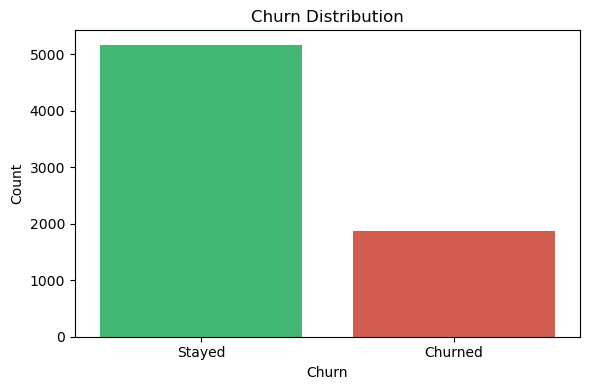

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Tenure vs Churn

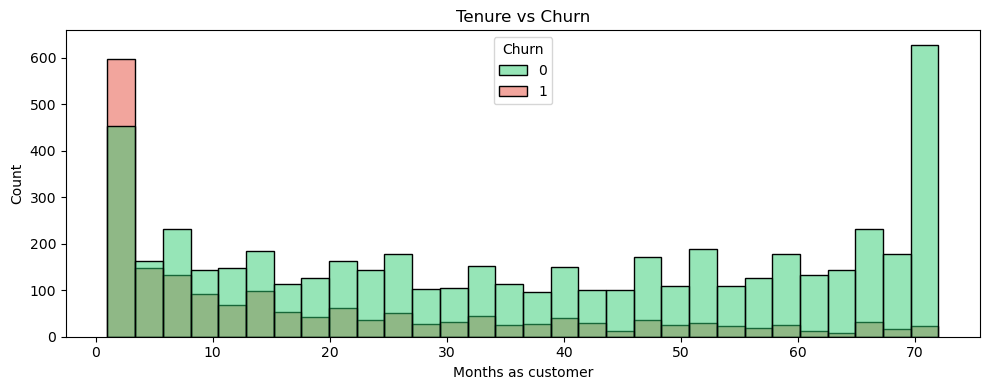

In [7]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure vs Churn')
plt.xlabel('Months as customer')
plt.tight_layout()
plt.show()

#### Monthly Charges vs Churn

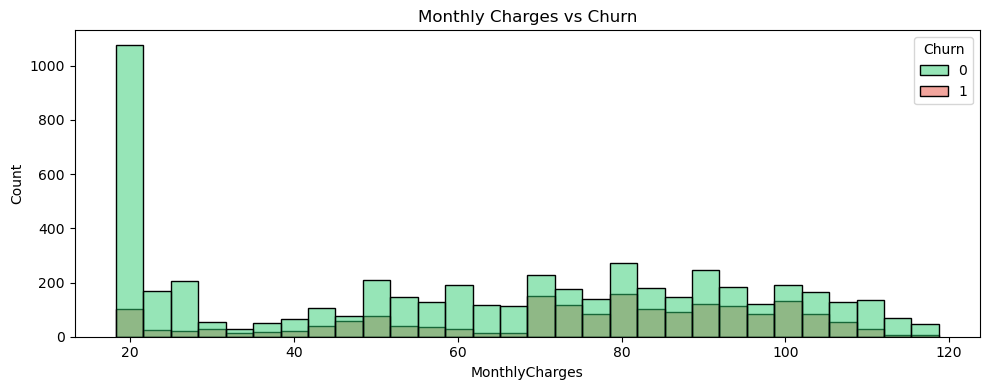

In [8]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

#### Contract Type vs Churn

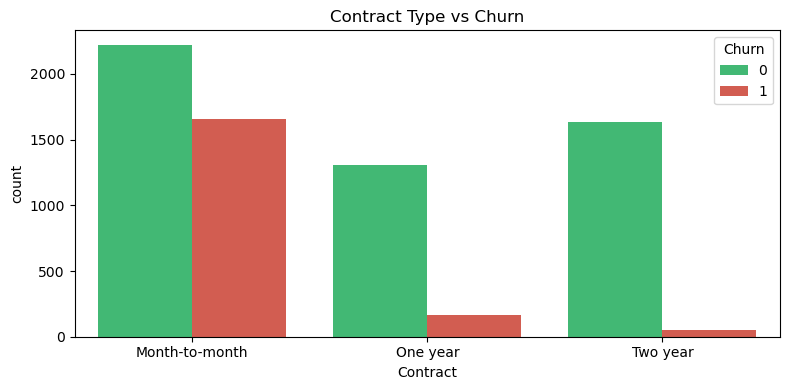

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()

#### Engineering New Features

In [10]:
df.drop('customerID', axis=1, inplace=True)

# Feature engineering
df['charge_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

df['num_services'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

df['is_new_customer'] = (df['tenure'] <= 3).astype(int)

df['high_risk_combo'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

print("New features added. Shape:", df.shape)
print(df[['charge_per_month', 'num_services', 'is_new_customer', 'high_risk_combo']].head())

New features added. Shape: (7032, 24)
   charge_per_month  num_services  is_new_customer  high_risk_combo
0         14.925000             1                1                0
1         53.985714             2                0                0
2         36.050000             2                1                0
3         40.016304             3                0                0
4         50.550000             0                1                1


In [11]:
from sklearn.preprocessing import LabelEncoder

# Columns that need encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAll columns now numeric:")
df.dtypes

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All columns now numeric:


gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
charge_per_month    float64
num_services          int64
is_new_customer       int64
high_risk_combo       int64
dtype: object

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nChurn rate in training set:", y_train.mean().round(3))
print("Churn rate in test set:", y_test.mean().round(3))

Training set: (5625, 23)
Test set: (1407, 23)

Churn rate in training set: 0.266
Churn rate in test set: 0.266


#### Class imbalance with SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "| Churn rate:", y_train.mean().round(3))
print("After SMOTE: ", X_train_balanced.shape, "| Churn rate:", y_train_balanced.mean().round(3))

Before SMOTE: (5625, 23) | Churn rate: 0.266
After SMOTE:  (8260, 23) | Churn rate: 0.5


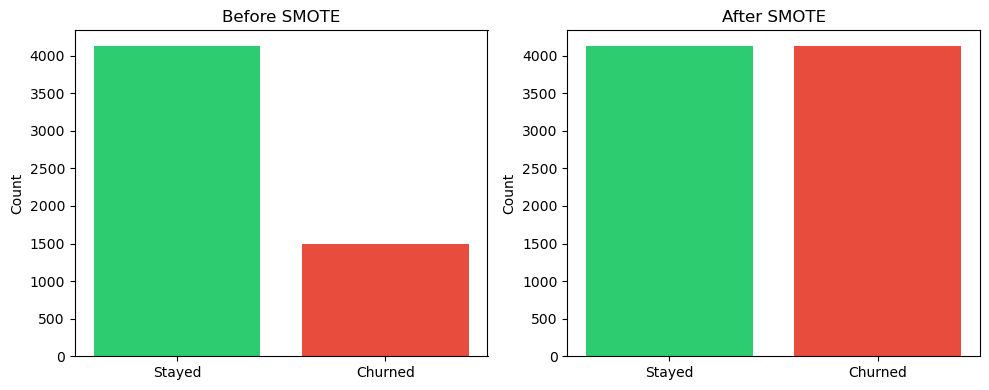

Before — Stayed: 4130, Churned: 1495
After  — Stayed: 4130, Churned: 4130


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(['Stayed', 'Churned'], 
            [sum(y_train == 0), sum(y_train == 1)], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

# After SMOTE
axes[1].bar(['Stayed', 'Churned'], 
            [sum(y_train_balanced == 0), sum(y_train_balanced == 1)], 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Before — Stayed: {sum(y_train == 0)}, Churned: {sum(y_train == 1)}")
print(f"After  — Stayed: {sum(y_train_balanced == 0)}, Churned: {sum(y_train_balanced == 1)}")

In [17]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_balanced, y_train_balanced)
print("Model trained.")

Model trained.


AUC-ROC Score: 0.8208

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.80      0.83      1033
     Churned       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.70      1407
weighted avg       0.77      0.76      0.76      1407



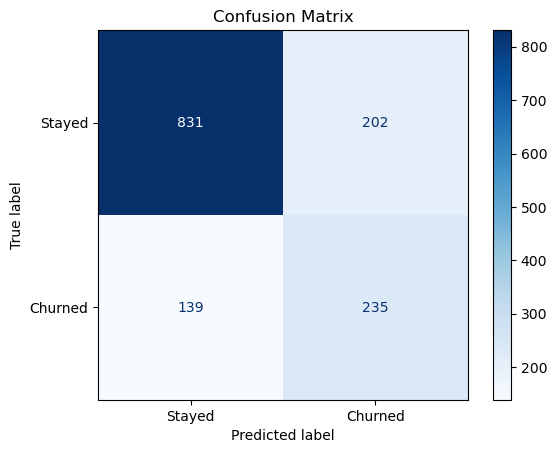

In [18]:
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("AUC-ROC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Tuned Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.76      0.82      1033
     Churned       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



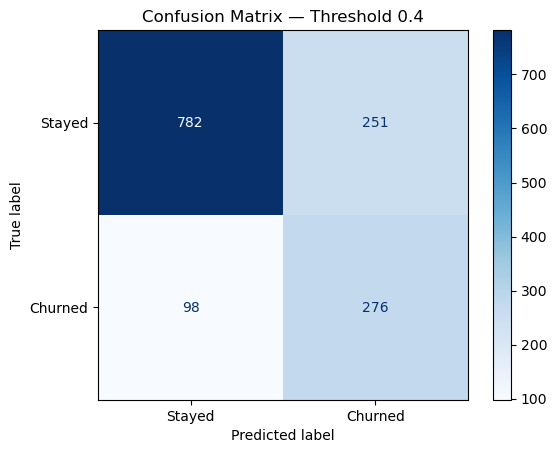

In [19]:
# Instead of default 0.5 threshold, lower it to catch more churners
threshold = 0.4
y_pred_tuned = (y_pred_proba >= threshold).astype(int)

print("Tuned Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Churned']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Threshold 0.4')
plt.show()

- Before tuning — caught 235 churners, missed 139
- After tuning  — caught 276 churners, missed 98

- 41 more churners caught. For a real business where each customer is worth £50-200/month, that's thousands in retained revenue. That's exactly the number you put in front of a client.
- The tradeoff — false alarms went from 202 to 251. Totally acceptable. An unnecessary check-in call costs nothing compared to losing a customer.

In [20]:
import joblib
import os

models_path = '../../models'
os.makedirs(models_path, exist_ok=True)

joblib.dump(model, f'{models_path}/churn_model.pkl')
joblib.dump(X.columns.tolist(), f'{models_path}/feature_columns.pkl')
joblib.dump(0.4, f'{models_path}/threshold.pkl')

print("Saved to /models:")
print("  churn_model.pkl")
print("  feature_columns.pkl")
print("  threshold.pkl")

Saved to /models:
  churn_model.pkl
  feature_columns.pkl
  threshold.pkl


/Users/shaheeraslam/miniforge3/envs/base-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


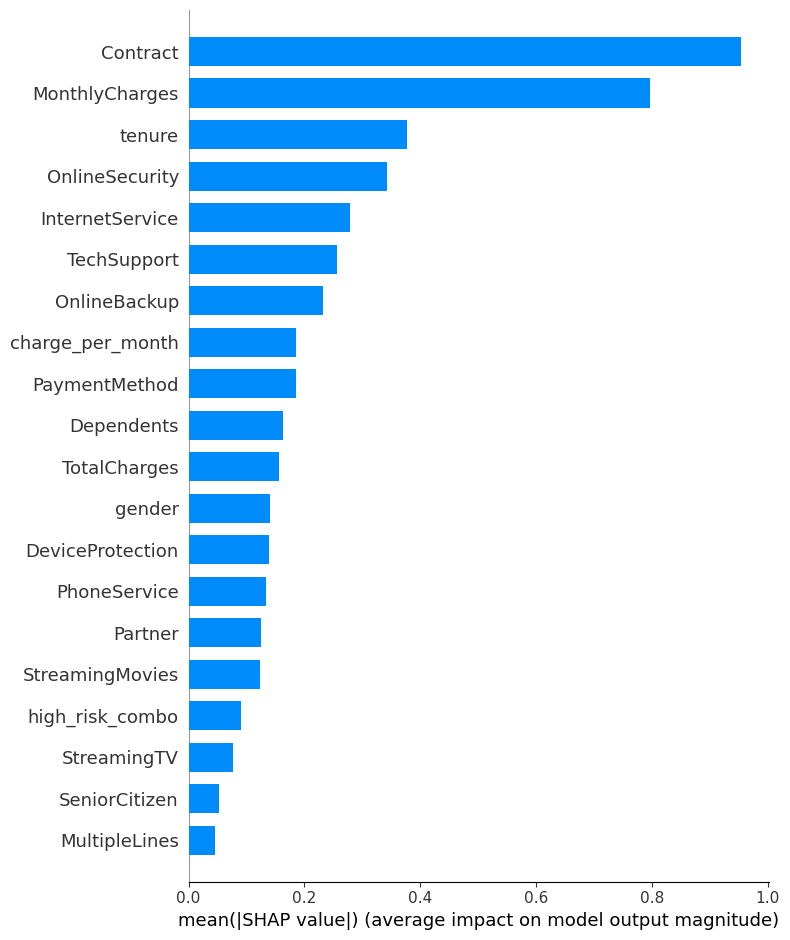

In [21]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Get SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most overall
shap.summary_plot(shap_values, X_test, plot_type='bar')

Churn probability : 1.73%
Actual outcome    : Stayed
Risk level        : LOW


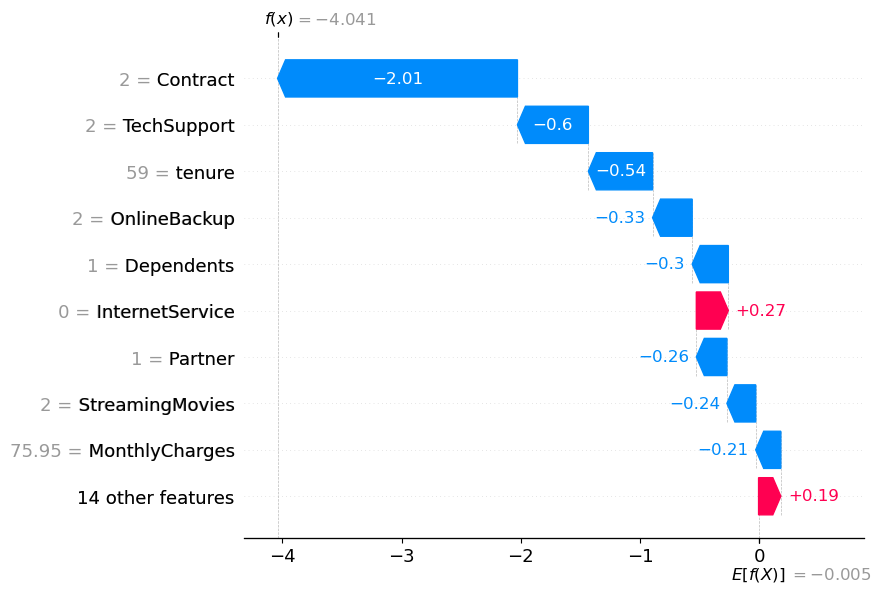

In [24]:
customer_idx = 0

prob = y_pred_proba[customer_idx]
actual = 'Churned' if y_test.iloc[customer_idx] == 1 else 'Stayed'

print(f"Churn probability : {prob:.2%}")
print(f"Actual outcome    : {actual}")
print(f"Risk level        : {'HIGH' if prob >= 0.6 else 'MEDIUM' if prob >= 0.4 else 'LOW'}")

# Waterfall plot — much more readable than force plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer_idx],
        feature_names=X_test.columns.tolist()
    )
)

In [23]:
def get_top_shap_reasons(shap_vals, feature_names, top_n=3):
    feature_shap = list(zip(feature_names, shap_vals))
    
    # Sort by absolute impact
    sorted_features = sorted(feature_shap, key=lambda x: abs(x[1]), reverse=True)
    
    reasons = []
    for feature, value in sorted_features[:top_n]:
        reasons.append({
            "feature": feature,
            "impact": round(float(value), 4),
            "direction": "increases risk" if value > 0 else "decreases risk"
        })
    
    return reasons

# Test it on first customer
reasons = get_top_shap_reasons(shap_values[0], X_test.columns.tolist())
for r in reasons:
    print(f"{r['feature']}: {r['impact']} ({r['direction']})")

Contract: -2.0129 (decreases risk)
TechSupport: -0.5951 (decreases risk)
tenure: -0.5388 (decreases risk)


In [25]:
# Save SHAP explainer alongside the model
joblib.dump(explainer, '../../models/shap_explainer.pkl')
print("SHAP explainer saved.")

SHAP explainer saved.


In [26]:
import os
files = os.listdir('../../models')
print("Files in /models:")
for f in files:
    print(f" ", f)

Files in /models:
  feature_columns.pkl
  threshold.pkl
  shap_explainer.pkl
  churn_model.pkl


Churn probability : 96.44%
Actual outcome    : Churned
Risk level        : HIGH


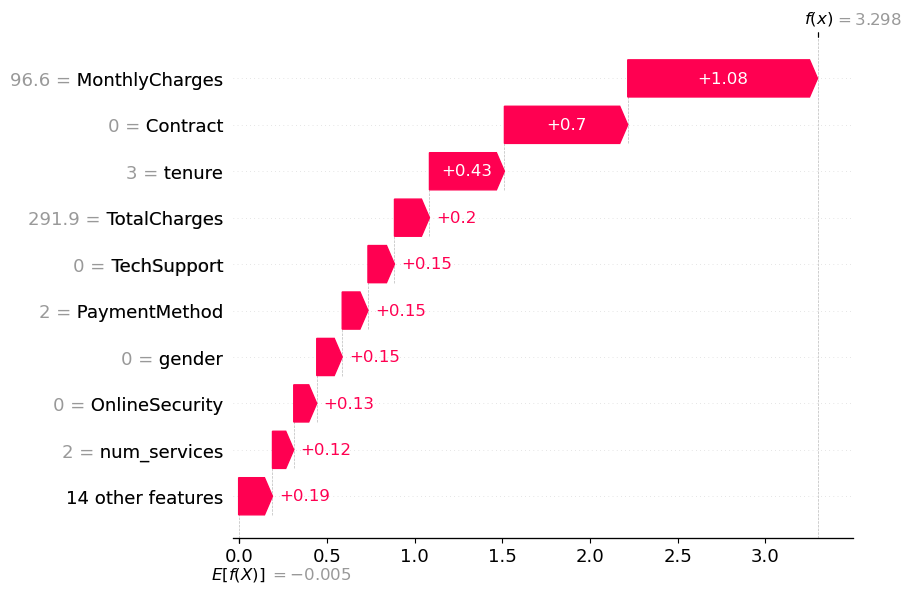

In [27]:
# Find a high risk customer
high_risk_idx = y_pred_proba.argmax()

prob = y_pred_proba[high_risk_idx]
actual = 'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Stayed'

print(f"Churn probability : {prob:.2%}")
print(f"Actual outcome    : {actual}")
print(f"Risk level        : HIGH")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    )
)

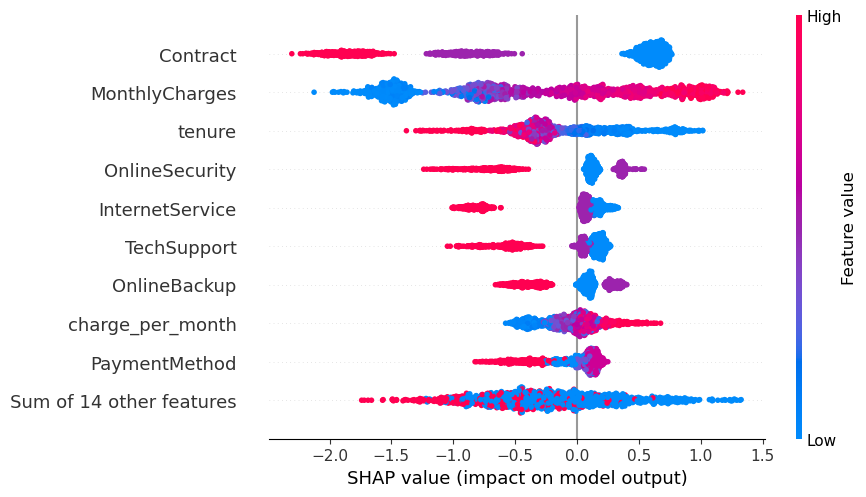

In [28]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_test.values,
        feature_names=X_test.columns.tolist()
    )
)

- Contract — pink dots (high value = long contract) are all the way left = massively reduces risk. Blue dots (month-to-month) push right = increases risk. Perfect separation.
- MonthlyCharges — pink dots spread right = high charges increase risk
- tenure — blue dots (new customers) push right = new customers at risk

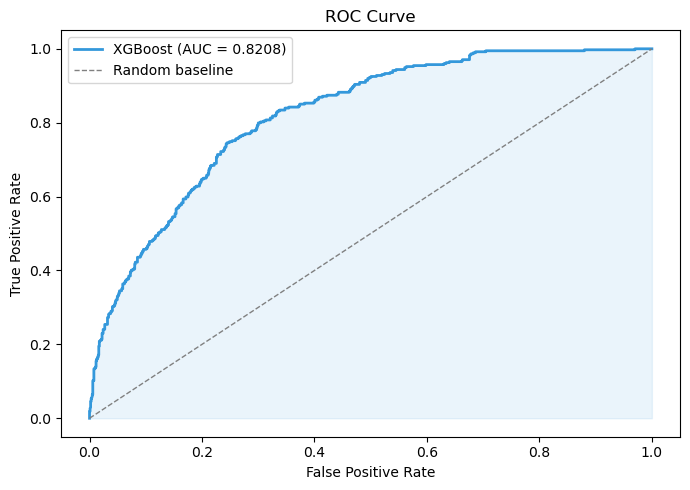

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random baseline')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

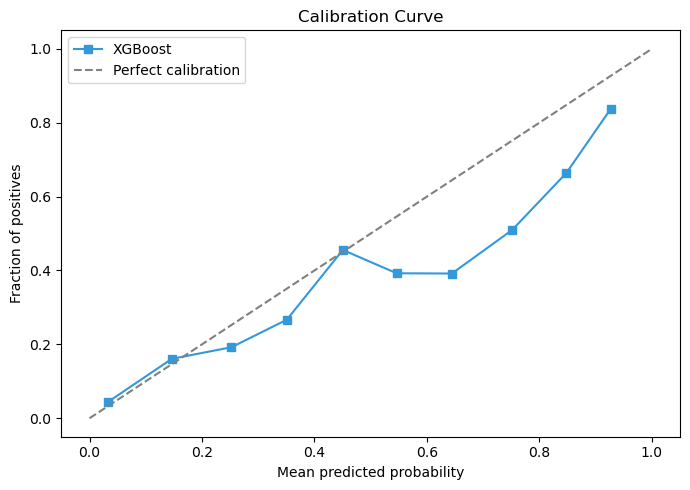

In [30]:
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(7, 5))
plt.plot(mean_pred, fraction_pos, 's-', color='#3498db', label='XGBoost')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print("Cross Validation AUC Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\nMean AUC : {cv_scores.mean():.4f}")
print(f"Std Dev  : {cv_scores.std():.4f}")

Cross Validation AUC Scores:
  Fold 1: 0.8441
  Fold 2: 0.8532
  Fold 3: 0.8455
  Fold 4: 0.8427
  Fold 5: 0.8422

Mean AUC : 0.8455
Std Dev  : 0.0040
